# **ANALYSIS OF ALGORITHMS**
# Homework 4

**Problem 1**


In [12]:
def minimize_max_pair_sum(sequence):
    #sort the sequence (O(n log n)) --> complexity
    sequence.sort()

    n_pairs = len(sequence) // 2
    pairs = []
    max_sum = 0

    #use of 2 pointers to pair the smallest with the largest (O(n))
    for i in range(n_pairs):
        left = sequence[i]
        right = sequence[len(sequence) - 1 - i]
        current_pair = (left, right)
        pairs.append(current_pair)

        #max sum
        current_sum = left + right
        if current_sum > max_sum:
            max_sum = current_sum

    return pairs, max_sum

numbers = [2, 4, 6, 9]
result_pairs, result_max = minimize_max_pair_sum(numbers)

print(f"Pairs: {result_pairs}")
print(f"Minimized Maximum Sum: {result_max}")

Pairs: [(2, 9), (4, 6)]
Minimized Maximum Sum: 11


**Problem 4**: Running time of O(n)

In [13]:
import math

def sort_array_few_distinct(A):

    n = len(A)
    if n <= 1:
        return A

    freq = {}
    for value in A:
        freq[value] = freq.get(value, 0) + 1

    distinct_values = list(freq.keys())
    distinct_values.sort()   # O(k log k)

    index = 0
    for value in distinct_values:
        count = freq[value]
        for _ in range(count):
            A[index] = value
            index += 1

    return A

#example usage
if __name__ == "__main__":
    A = [100, 5, 100, 7, 5, 100, 7, 5]
    print("Original:", A)
    sorted_A = sort_array_few_distinct(A)
    print("Sorted:", sorted_A)

Original: [100, 5, 100, 7, 5, 100, 7, 5]
Sorted: [5, 5, 5, 7, 7, 100, 100, 100]




---



**Problem 6**

# **Comparative study between quicksort, mergesort and heapsort**

Before we start our implementation, we need to impirto the needed libraries:

In [14]:
import random
import time
import math
import pandas as pd
import matplotlib.pyplot as plt

**Input Sizes**

We evaluate the algorithms using arrays of the following sizes:

- 10^2

- 10^3

- 10^4

- 10^5

- 10^6

And for each size, we will have 3 types of input data generated like random values, and a sorting for an ascending and descending order.

Have in mind that this experiment has a goal, and is to analyze their empirical performance across different input sizes and distributions.

Now, let's generate some data

In [15]:
def generate_data(n, kind, seed=123):
    random.seed(seed)

    if kind == "random":
        # random
        return [random.randint(0, 10**7) for _ in range(n)]

    elif kind == "sorted_asc":
        # ascending
        return list(range(n))

    elif kind == "sorted_desc":
        # descending
        return list(range(n, 0, -1))

Let's start with the algorithm implementation:

▶ **Quicksort**: Divide-and-conquer based on partitioning. Using a random pivot selection to avoid an encounter on a worst case.

It's complexity on an average case is $O(n log n)$. For a worst case scenario is $O(n^2)$.



In [21]:
def quicksort(arr):

    def partition(a, low, high):
        pivot_index = random.randint(low, high)
        a[pivot_index], a[high] = a[high], a[pivot_index]
        pivot = a[high]

        i = low - 1
        for j in range(low, high):
            if a[j] <= pivot:
                i += 1
                a[i], a[j] = a[j], a[i]

        a[i+1], a[high] = a[high], a[i+1]
        return i + 1

    def _quicksort(a, low, high):
        if low < high:
            p = partition(a, low, high)
            _quicksort(a, low, p-1)
            _quicksort(a, p+1, high)

    _quicksort(arr, 0, len(arr)-1)
    return arr

▶ **Mergesort**: A sorting algorithm that is more stable version of divide-and-conquer, where we need to do a division of the array into 2 halves as a first step, then sort each half to finally merge them into a single sorted array.

In complexity terms, for all the possible cases, we obtain $O(n log n)$.



In [23]:
def mergesort(arr):
    temp = [0] * len(arr)

    def merge(a, temp, left, mid, right):
        i, j, k = left, mid+1, left
        while i <= mid and j <= right:
            if a[i] <= a[j]:
                temp[k] = a[i]
                i += 1
            else:
                temp[k] = a[j]
                j += 1
            k += 1

        while i <= mid:
            temp[k] = a[i]
            i += 1
            k += 1

        while j <= right:
            temp[k] = a[j]
            j += 1
            k += 1

        for idx in range(left, right+1):
            a[idx] = temp[idx]

    def _mergesort(a, temp, left, right):
        if left >= right:
            return
        mid = (left + right) // 2
        _mergesort(a, temp, left, mid)
        _mergesort(a, temp, mid+1, right)
        merge(a, temp, left, mid, right)

    _mergesort(arr, temp, 0, len(arr)-1)
    return arr

▶**Heapsort**: This algorithm based its function on the heap data structure. It will transform the array into a max-heap, swap the max element with the last element, reduce this heap size and restore the heap property, to finally repeat this process until all is sorted.

In complexity terms, for all possible scenarios will be $O(n log n)$

In [18]:
def heapsort(arr):
    n = len(arr)

    def heapify(a, n, i):
        largest = i
        left = 2*i + 1
        right = 2*i + 2

        if left < n and a[left] > a[largest]:
            largest = left

        if right < n and a[right] > a[largest]:
            largest = right

        if largest != i:
            a[i], a[largest] = a[largest], a[i]
            heapify(a, n, largest)

    for i in range(n//2 - 1, -1, -1):
        heapify(arr, n, i)

    for end in range(n-1, 0, -1):
        arr[0], arr[end] = arr[end], arr[0]
        heapify(arr, end, 0)
    return arr

Now that we have all the algorithms ready, we can do a full test between them 3 with all our sizes and types.



In [24]:
def time_algorithm(sort_func, data, repeats=3):

    total = 0.0
    for _ in range(repeats):
        arr_copy = data[:]
        start = time.perf_counter()
        sort_func(arr_copy)
        end = time.perf_counter()
        total += (end - start)

    return total / repeats

def run_benchmark():
    sizes = [10**2, 10**3, 10**4, 10**5, 10**6]
    kinds = ["random", "sorted_asc", "sorted_desc"]
    algorithms = {
        "Quicksort": quicksort,
        "Mergesort": mergesort,
        "Heapsort": heapsort}

    rows = []
    for n in sizes:
        # Repeticiones adaptativas (más pequeño => más repeticiones)
        if n <= 10**4:
            repeats = 5
        elif n <= 10**5:
            repeats = 3
        else:
            repeats = 1  # para 10^6 normalmente basta 1

        for kind in kinds:
            data = generate_data(n, kind, seed=123)

            for alg_name, alg_func in algorithms.items():
                # para quicksort usamos pivote aleatorio: fijamos semilla para comparabilidad
                random.seed(123)
                t = time_algorithm(alg_func, data, repeats=repeats)
                rows.append({
                    "n": n,
                    "data_type": kind,
                    "algorithm": alg_name,
                    "time_sec": t,
                    "repeats": repeats})

    return pd.DataFrame(rows)

df = run_benchmark()

After this testing, we can compare all the results in the next tables:

In [30]:
for kind in df["data_type"].unique():
    print("DATA TYPE:", kind)
    display(df[df["data_type"] == kind]
            .pivot_table(index="n",
                         columns="algorithm",
                         values="time_sec",
                         aggfunc="mean"))

DATA TYPE: random


algorithm,Heapsort,Mergesort,Quicksort
n,,,
100,0.000150,0.000140,0.000113
1000,0.005081,0.002198,0.002188
10000,0.035585,0.028381,0.021929
100000,0.584553,0.375524,0.277998
1000000,9.916946,6.806216,3.944651


DATA TYPE: sorted_asc


algorithm,Heapsort,Mergesort,Quicksort
n,,,
100,0.000189,0.000112,0.000102
1000,0.002552,0.001880,0.002943
10000,0.036786,0.024841,0.020927
100000,0.481095,0.537309,0.487465
1000000,7.495883,3.620716,2.907226


DATA TYPE: sorted_desc


algorithm,Heapsort,Mergesort,Quicksort
n,,,
100,0.000245,0.000183,0.000220
1000,0.002173,0.001849,0.001560
10000,0.032037,0.027891,0.020306
100000,0.440883,0.308174,0.235991
1000000,7.162166,3.561207,2.880241


It is possible to see that the rows represent the input size we already defined at the beginning of this analysis. The columns show the sorting algorithm.

Each table corresponds to a specific input distribution.

Finally, we can show these numbers in a visual way. By using logarithmic plots because our input sizes grow in an exponential way.

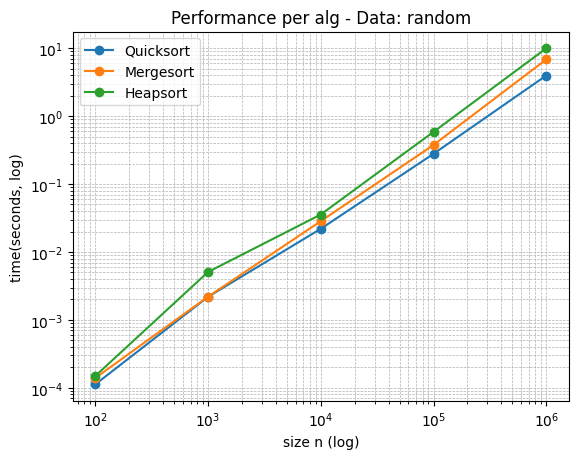

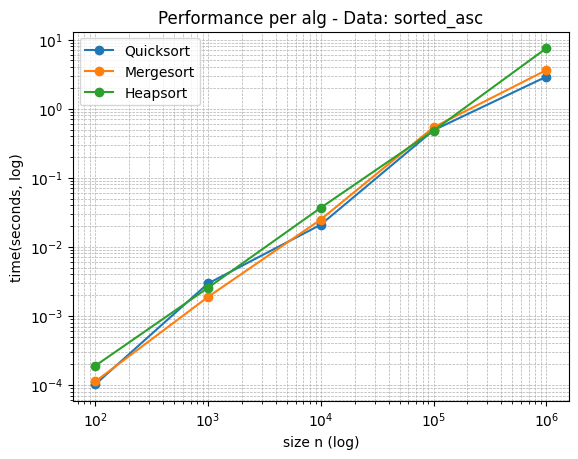

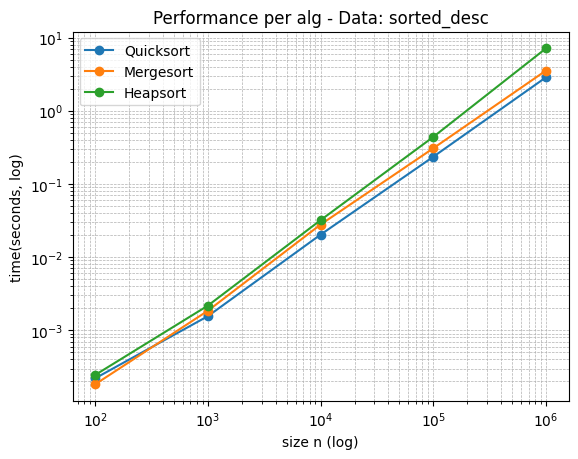

In [32]:
def plot_results(df):
    data_types = df["data_type"].unique()

    for kind in data_types:
        subset = df[df["data_type"] == kind]

        plt.figure()
        for alg in subset["algorithm"].unique():
            alg_data = subset[subset["algorithm"] == alg].sort_values("n")
            plt.plot(alg_data["n"], alg_data["time_sec"], marker="o", label=alg)

        plt.xscale("log")
        plt.yscale("log")
        plt.xlabel("size n (log)")
        plt.ylabel("time(seconds, log)")
        plt.title(f"Performance per alg - Data: {kind}")
        plt.legend()
        plt.grid(True, which="both", linestyle="--", linewidth=0.5)
        plt.show()

plot_results(df)



---



**Results interpretation**

*Random Data* - For randomly generated inputs, all three algorithms exhibit behavior consistent with $O(n log n)$.

- Mergesort remains stable and predictable.
- Heapsort also shows consistent performance independent of input order.
- Quicksort typically performs very well in practice when using a random pivot.

▶ In this scenario, **Quicksort** and **Mergesort** often achieve the best performance.



*Ascending Sorted Data* - When the input is already sorted in ascending order:
- Mergesort maintains stable performance.
- Heapsort remains largely unaffected.
- Quicksort could degrade if a poor pivot strategy is used, but random pivot selection significantly mitigates this risk.

*Descending Sorted Data* - Descending input behaves similarly to ascending input:

- Mergesort and Heapsort remain stable.
- Quicksort’s performance depends on pivot randomness but generally remains close to O(n log n) on average.

**Conclusions**

Presented as a list:

- Mergesort is the most stable algorithm, as its performance is independent of input ordering.
- Heapsort is consistent and memory-efficient but may have slightly larger constant factors.
- Quicksort is often the fastest in practice, provided that pivot selection avoids pathological cases.

▶ For very large inputs, Python implementations may become slow.

*Overall, empirical results align closely with theoretical complexity analysis.*
